# 2 - Interval Analysis

## Imports

In [6]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

In [118]:
import pandas as pd
from fractions import Fraction
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm
import music21 as m21

import sys
sys.path.append('/Users/Jessica/Documents/ERIP2025/Jessica-ERIP2025/')

from Importables import General as g
from Importables import intervalanalysis_utils as ia

## In-Label Intervals

In [121]:
metadata = g.load_metadata()

subset = metadata[(metadata['workTitle'] == 'Four') | (metadata['workTitle'] == 'Blues By Five')]
subset = subset[subset['artists'].isin(['John Coltrane', 'Miles Davis'])]

labels = g.load_labels(subset)
labels.head()

,mc,mn,quarterbeats,quarterbeats_all_endings,duration_qb,mc_onset,mn_onset,timesig,staff,voice,harmony_layer,label,regex_match,artist,workTitle,fnames,rel_paths,recording_year,time,ILS
0,1,1,0,0,4.0,0.0,0,4/4,1,1,3,B-7,NaN,John Coltrane,Blues By Five,Blues By Five - John Coltrane (Concert Key),by_Carles_Margarit,1956,1.0,"[B-, D, F, A-]"
1,2,2,4,4,4.0,0.0,0,4/4,1,1,3,E-7,NaN,John Coltrane,Blues By Five,Blues By Five - John Coltrane (Concert Key),by_Carles_Margarit,1956,2.0,"[E-, G, B-, D-]"
2,3,3,8,8,4.0,0.0,0,4/4,1,1,3,B-7,NaN,John Coltrane,Blues By Five,Blues By Five - John Coltrane (Concert Key),by_Carles_Margarit,1956,3.0,"[B-, D, F, A-]"
3,4,4,12,12,4.0,0.0,0,4/4,1,1,3,B-7,NaN,John Coltrane,Blues By Five,Blues By Five - John Coltrane (Concert Key),by_Carles_Margarit,1956,4.0,"[B-, D, F, A-]"
4,5,5,16,16,4.0,0.0,0,4/4,1,1,3,E-7,NaN,John Coltrane,Blues By Five,Blues By Five - John Coltrane (Concert Key),by_Carles_Margarit,1956,5.0,"[E-, G, B-, D-]"


In [161]:
ILC = labels.copy()
ILC['interval'] = ILC['label'].apply(ia.label_to_intervals)
ILC = ILC.groupby(['artist', 'workTitle'], as_index=False).agg(list)
ILC

,artist,workTitle,mc,mn,quarterbeats,quarterbeats_all_endings,duration_qb,mc_onset,mn_onset,timesig,...,voice,harmony_layer,label,regex_match,fnames,rel_paths,recording_year,time,ILS,interval
0,John Coltrane,Blues By Five,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 11, 12, 12...","[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 11, 12, 12...","[0, 4, 8, 12, 16, 20, 24, 28, 32, 36, 40, 42, ...","[0, 4, 8, 12, 16, 20, 24, 28, 32, 36, 40, 42, ...","[4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1/2, 0, 1/2,...","[4/4, 4/4, 4/4, 4/4, 4/4, 4/4, 4/4, 4/4, 4/4, ...",...,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, ...","[B-7, E-7, B-7, B-7, E-7, E-7, B-7, G7b9, Cmin...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[Blues By Five - John Coltrane (Concert Key), ...","[by_Carles_Margarit, by_Carles_Margarit, by_Ca...","[1956, 1956, 1956, 1956, 1956, 1956, 1956, 195...","[1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, ...","[[B-, D, F, A-], [E-, G, B-, D-], [B-, D, F, A...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ..."
1,John Coltrane,Four,"[9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 18, 19...","[9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 18, 19...","[32, 36, 40, 44, 48, 52, 56, 60, 64, 68, 70, 7...","[32, 36, 40, 44, 48, 52, 56, 60, 64, 68, 70, 7...","[4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1/2, 0, 0, 0, 0...","[4/4, 4/4, 4/4, 4/4, 4/4, 4/4, 4/4, 4/4, 4/4, ...",...,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, ...","[E-maj7, E-maj7, B-min7, E-7, A-maj7, A-maj7, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[Four - John Coltrane (Concert Key), Four - Jo...","[by_Carles_Margarit, by_Carles_Margarit, by_Ca...","[1956, 1956, 1956, 1956, 1956, 1956, 1956, 195...","[9.0, 10.0, 11.0, 12.0, 13.0, 14.0, 15.0, 16.0...","[[E-, G, B-, D], [E-, G, B-, D], [B-, D-, F, A...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ..."
2,Miles Davis,Blues By Five,"[1, 1, 2, 3, 4, 5, 6, 7, 8, 10, 11, 11, 12, 12...","[1, 1, 2, 3, 4, 5, 6, 7, 8, 10, 11, 11, 12, 12...","[0, 0, 4, 8, 12, 33/2, 41/2, 24, 57/2, 36, 40,...","[0, 0, 4, 8, 12, 33/2, 41/2, 24, 57/2, 36, 40,...","[0.0, 4.0, 4.0, 4.0, 4.5, 4.0, 3.5, 4.5, 7.5, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.125, 0.125, 0.0, 0...","[0, 0, 0, 0, 0, 1/8, 1/8, 0, 1/8, 0, 0, 3/4, 0...","[4/4, 4/4, 4/4, 4/4, 4/4, 4/4, 4/4, 4/4, 4/4, ...",...,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, ...","[E-7, B-7, E-7, B-7, B-7, Cmin7, E-7, B-7, G7b...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[Blues By Five - Miles Davis (Concert Key), Bl...","[by_Carles_Margarit, by_Carles_Margarit, by_Ca...","[1956, 1956, 1956, 1956, 1956, 1956, 1956, 195...","[1.0, 1.0, 2.0, 3.0, 4.0, 5.125, 6.125, 7.0, 8...","[[E-, G, B-, D-], [B-, D, F, A-], [E-, G, B-, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ..."
3,Miles Davis,Four,"[9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 18, 19...","[9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 18, 19...","[32, 36, 40, 44, 48, 52, 56, 60, 64, 68, 70, 7...","[32, 36, 40, 44, 48, 52, 56, 60, 64, 68, 70, 7...","[4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1/2, 0, 0, 0, 0...","[4/4, 4/4, 4/4, 4/4, 4/4, 4/4, 4/4, 4/4, 4/4, ...",...,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, ...","[Fmaj7, Fmaj7, Cmin7, F7, B-maj7, B-maj7, B-mi...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[Four - Miles Davis (Concert Key), Four - Mile...","[by_Carles_Margarit, by_Carles_Margarit, by_Ca...","[1956, 1956, 1956, 1956, 1956, 1956, 1956, 195...","[9.0, 10.0, 11.0, 12.0, 13.0, 14.0, 15.0, 16.0...","[[F, A, C, E], [F, A, C, E], [C, E-, G, B-], [...","[

In [125]:
songs, artists, data = ia.create_data(ILC)

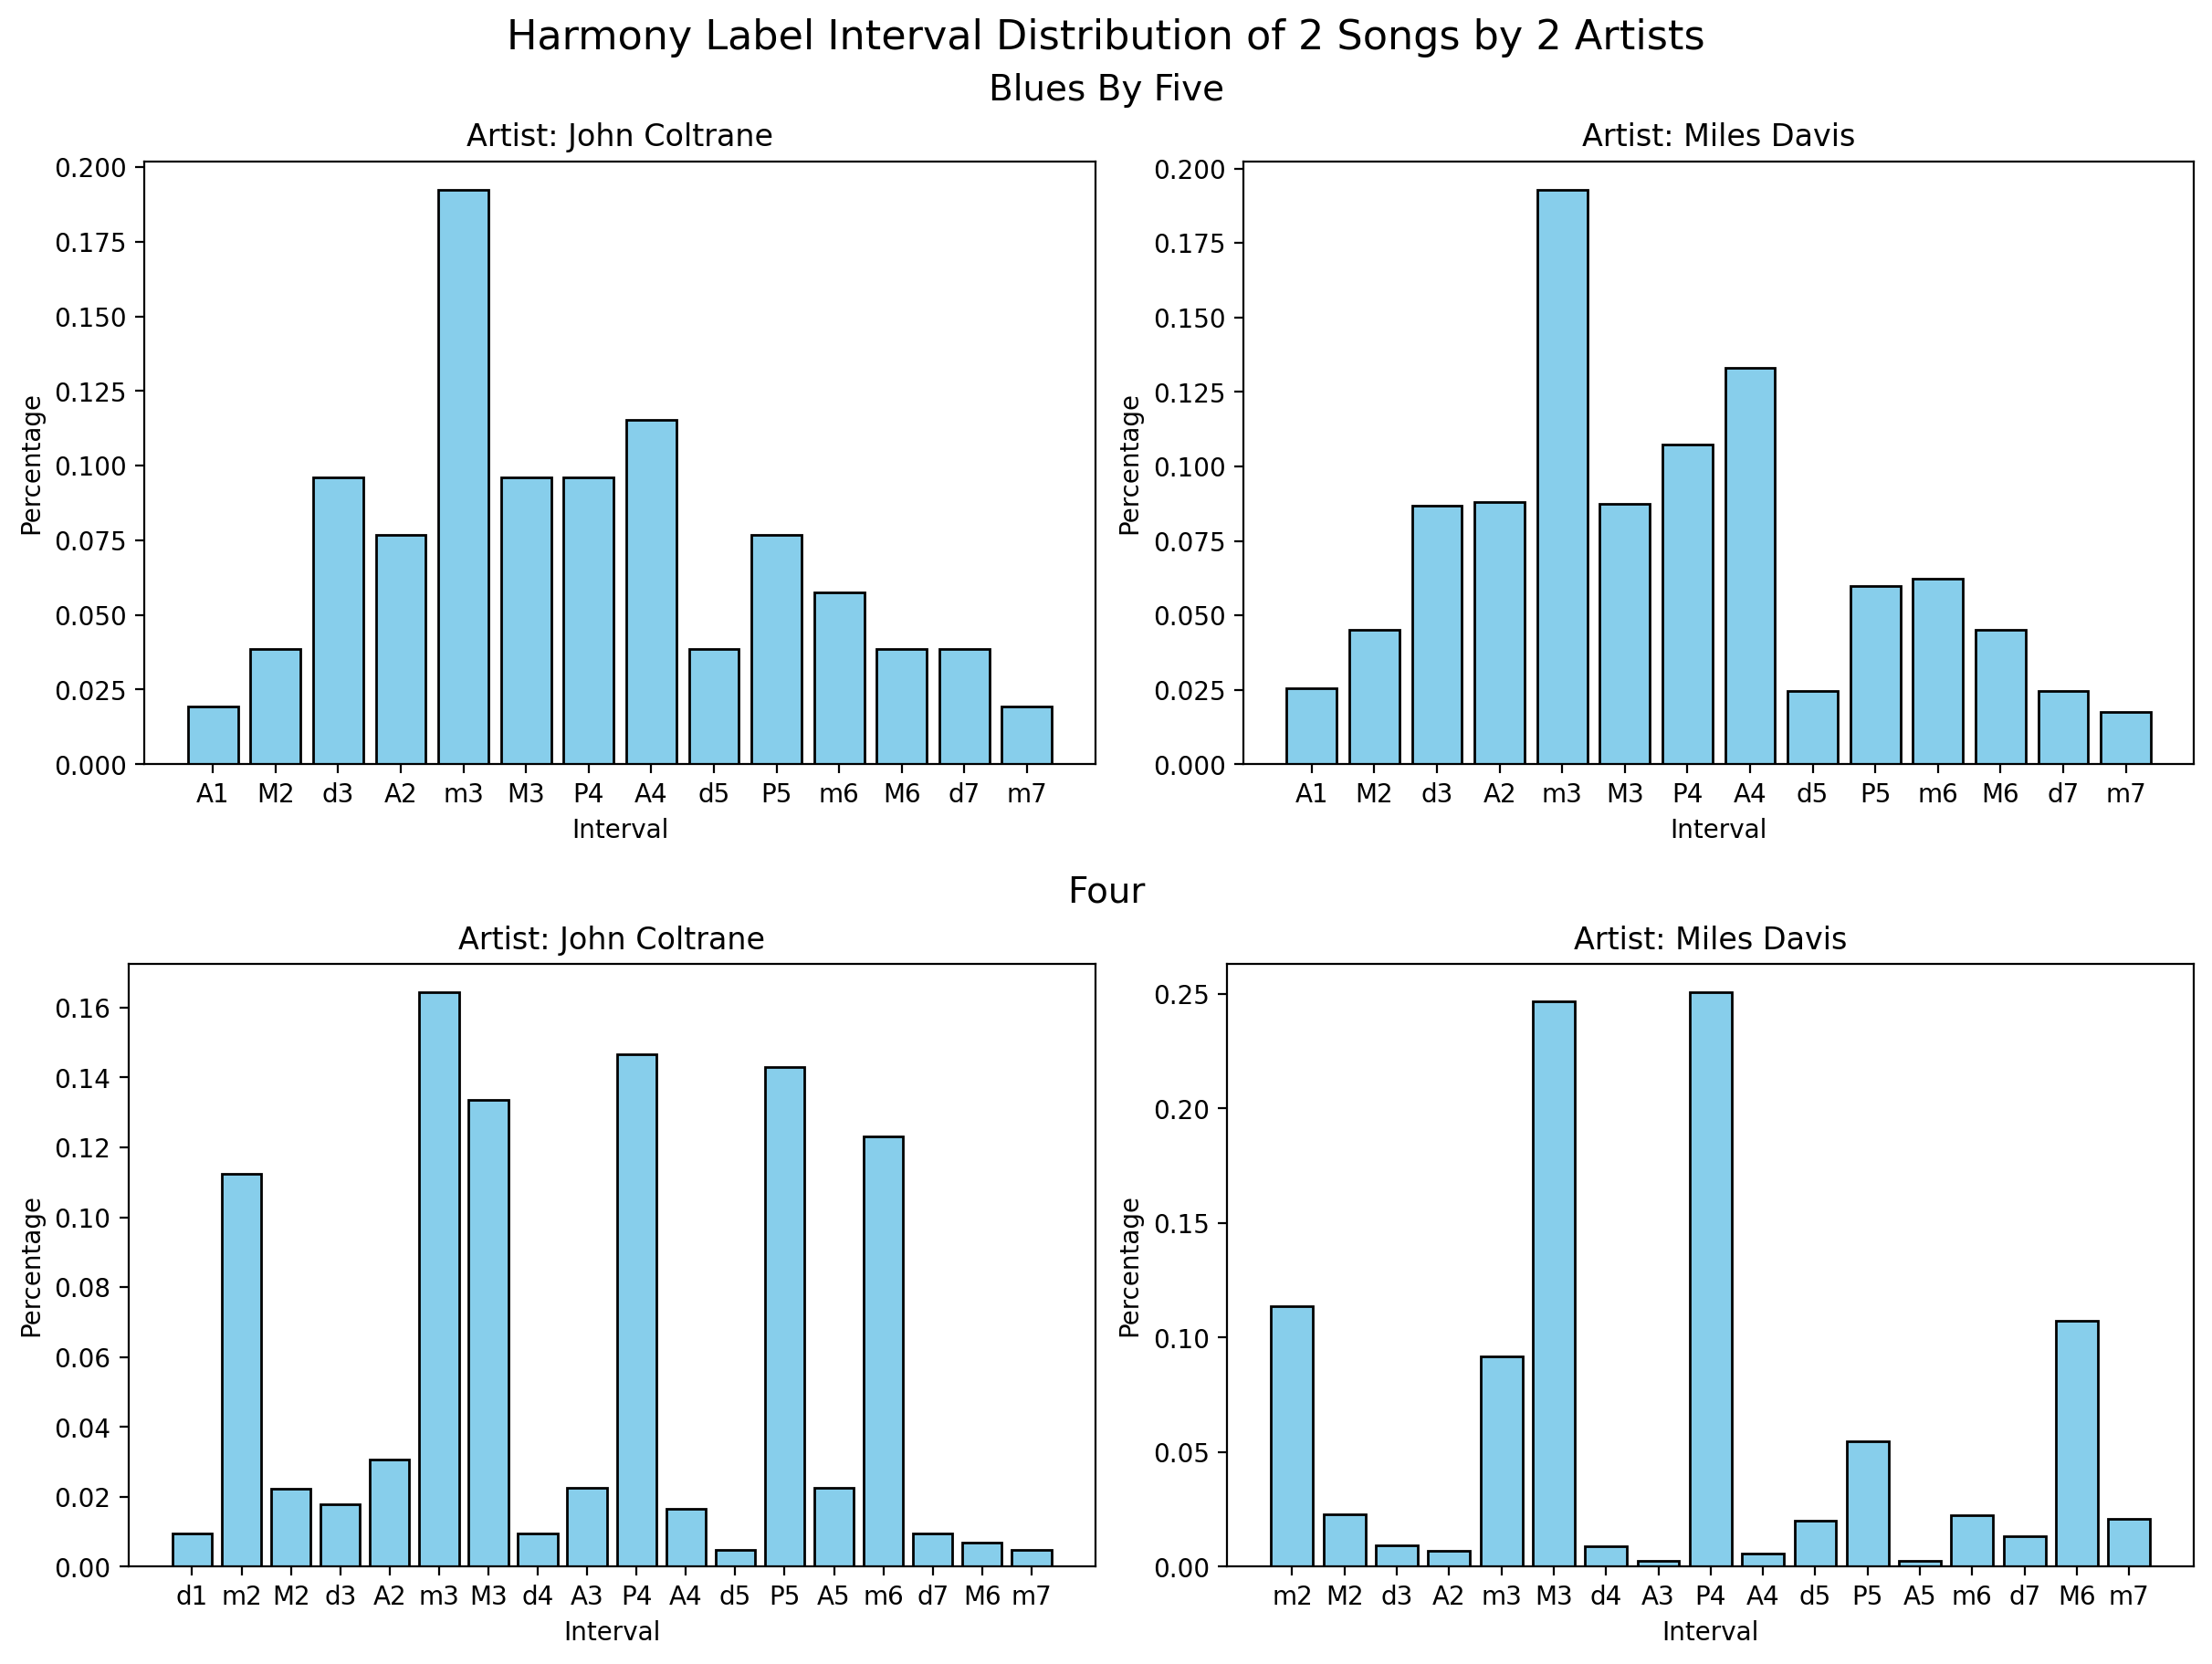

In [127]:
ia.plot_interval_distribution(songs, artists, data)

- Next step: notes sounding simultaneously (consider duration !!!)
- Debug: look at two pieces in same key and two pieces in different keys to look at the interval and pitch class
- group plots by artist or key or year 

## Harmony Interval Analysis

### Example: Shapons Vindaloo by Snarky Puppy

In [132]:
# Load score and chordify
score_path = "/Users/Jessica/Documents/ERIP2025/Jessica-ERIP2025/jazz_transcriptions/by_Alexander_Booker/Snarky_Puppy-Shapons_Vindaloo.xml"
score = m21.converter.parse("/Users/Jessica/Documents/ERIP2025/Jessica-ERIP2025/jazz_transcriptions/by_Alexander_Booker/Snarky_Puppy-Shapons_Vindaloo.xml")
for h in score.recurse().getElementsByClass('Harmony'):
    score.remove(h, recurse=True)
chords = score.chordify()

# Build list of dictionaries to collect data
rows = []

for thisChord in chords.recurse().getElementsByClass(chord.Chord):
    h = [p for p in thisChord.pitches]
    intervals, semitones = ia.get_intervals_semitones(h)
    start_time = thisChord.offset
    duration = thisChord.quarterLength

    rows.append({
        'time': start_time,
        'duration': duration,
        'harmony': h,
        'interval': intervals,
        'semitones': semitones
    })

# Convert to DataFrame
harmony = pd.DataFrame(rows)
harmony = harmony[harmony['harmony'].apply(lambda x: len(x) > 1)]

harmony.head()

,time,duration,harmony,intervals,semitones
0,1.5,3.0,"[A-3, D4, A-4]","[A4, P1, d5]","[6, 12, 6]"
1,0.0,1.0,"[G3, D4, G4]","[P5, P1, P4]","[7, 12, 5]"
2,1.0,1.0,"[F3, G3, D4, G4]","[M2, M6, M2, P5, P1, P4]","[2, 9, 14, 7, 12, 5]"
3,2.0,1.5,"[G3, D4, G4]","[P5, P1, P4]","[7, 12, 5]"
21,1.5,1.0,"[F3, A-3, D4, A-4]","[m3, M6, m3, A4, P1, d5]","[3, 9, 15, 6, 12, 6]"


Text(0, 0.5, 'Percentage')

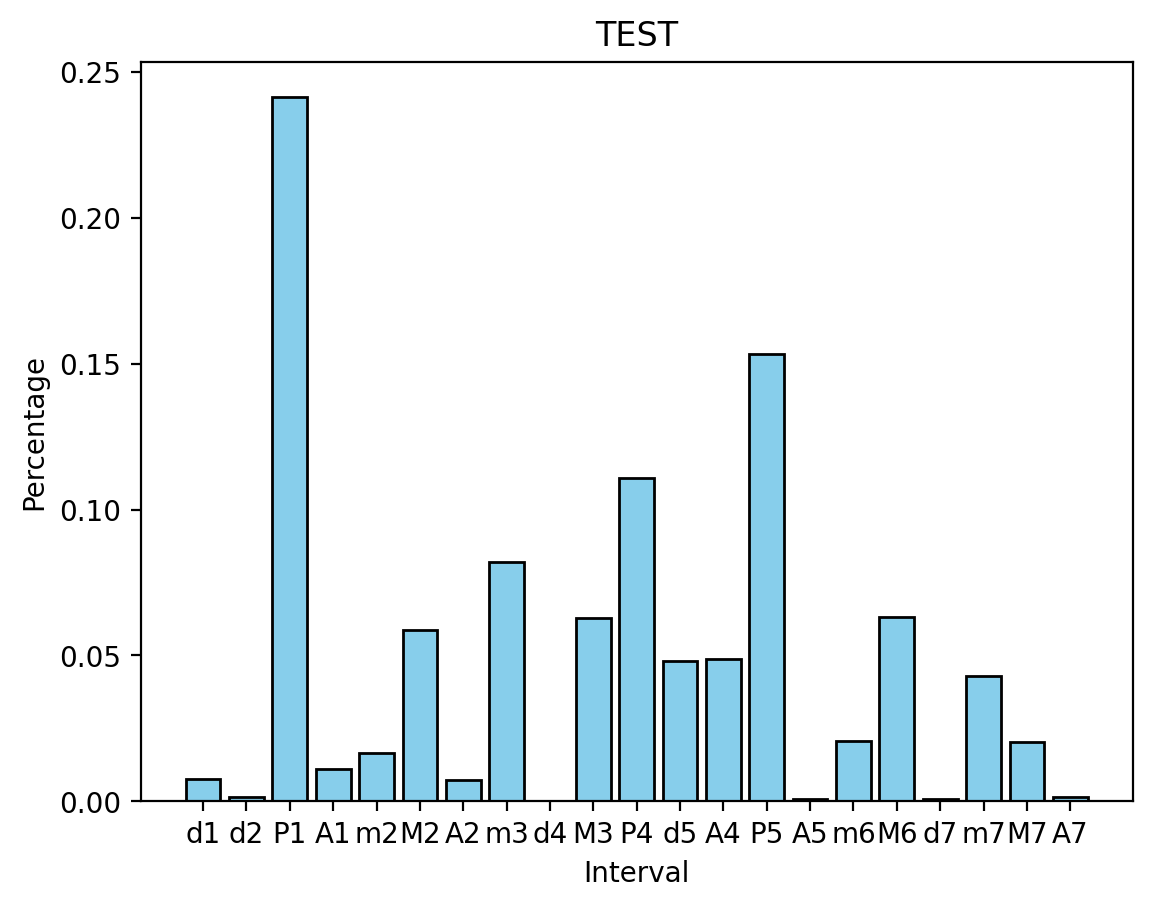

In [134]:
interval = harmony[['interval', 'duration']]
interval = interval.explode(['interval'])

interval_counts = (
    interval.groupby(['interval'])['duration']
    .sum()
    .reset_index(name='weighted_count')
)

interval_counts['semitone'] = interval_counts['interval'].apply(lambda x: m21.interval.Interval(x).semitones)
count = interval_counts.sort_values('semitone')
total = count['weighted_count'].sum()
count['percentage'] = count['weighted_count'] / total

# Plot bar chart
plt.bar(count['interval'], count['percentage'], color='skyblue', edgecolor='black')
plt.title("TEST")
plt.xlabel('Interval')
plt.ylabel('Percentage')

### Example: Subset

In [239]:
metadata = g.load_metadata()
subset = metadata[(metadata['workTitle'] == 'Four') | (metadata['workTitle'] == 'Blues By Five')]
subset = subset[subset['artists'].isin(['John Coltrane', 'Miles Davis'])]

harmonies_subset = g.load_harmonies(subset)


In [241]:
harmonies_subset = harmonies_subset.groupby(['artist', 'workTitle'], as_index=False).agg(list)
songs, artists, data = ia.create_data(harmonies_subset)

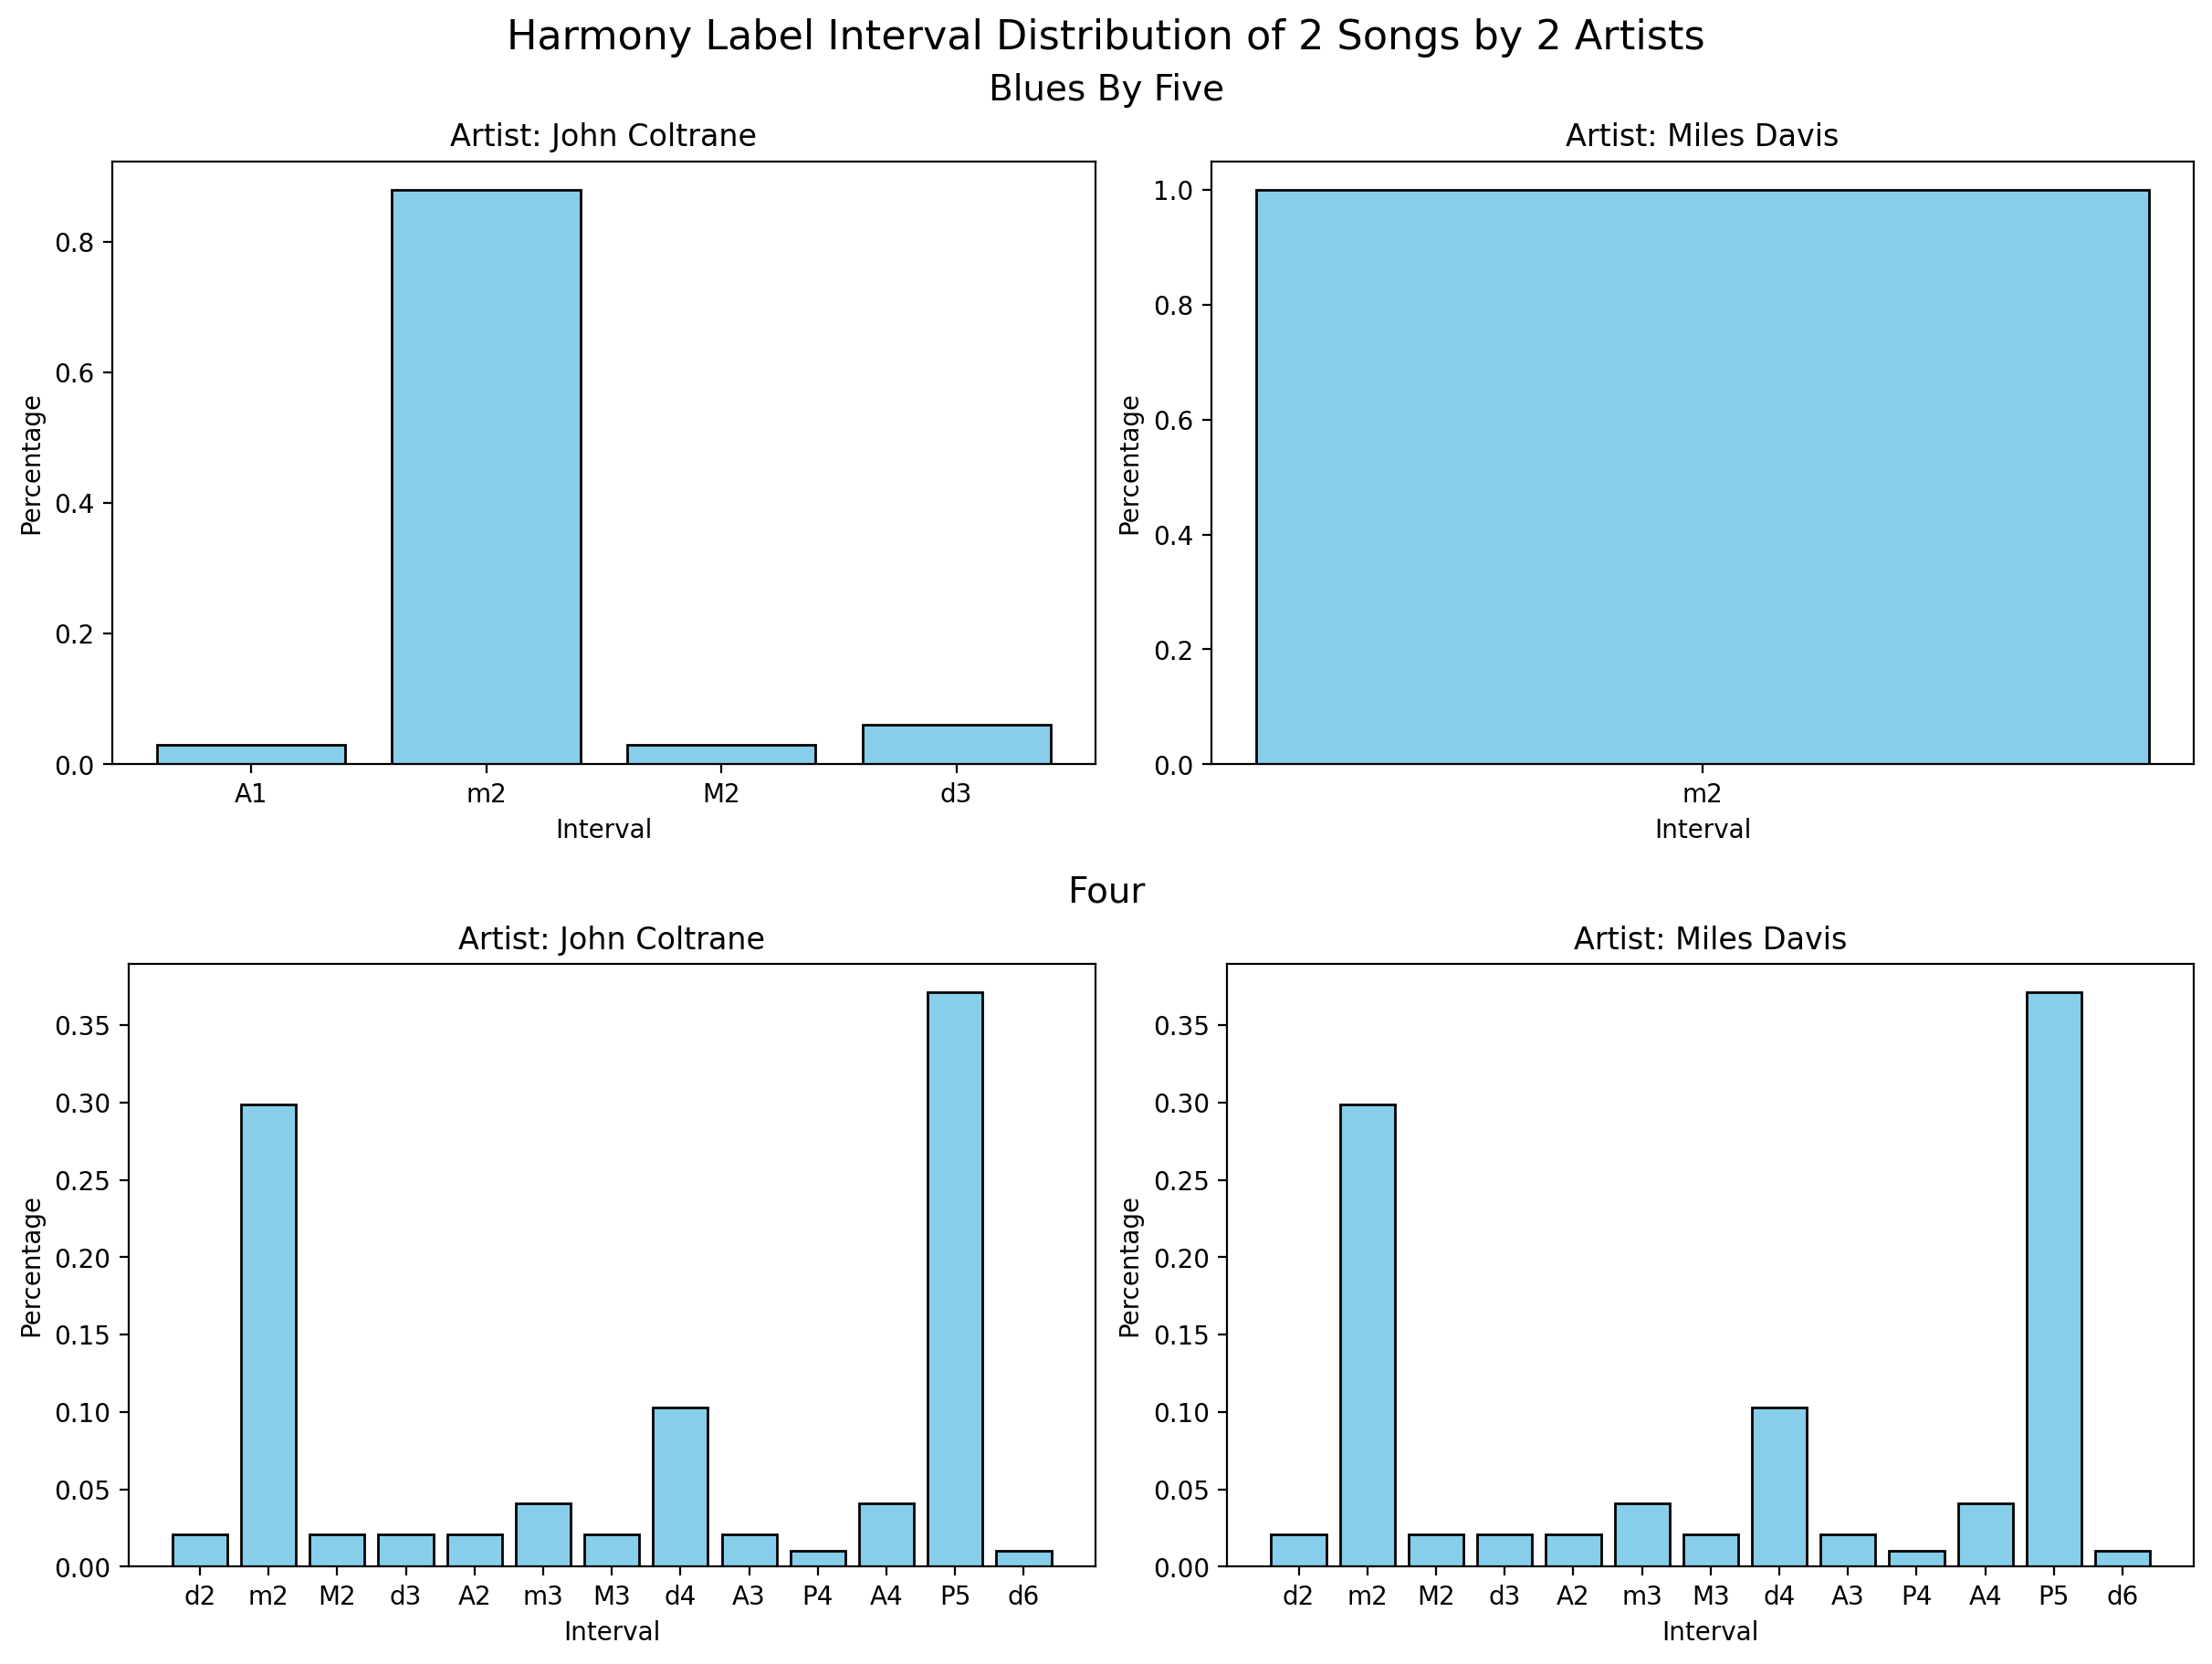

In [243]:
ia.plot_interval_distribution(songs, artists, data)

## By Artist